# Financial Persona Clustering — Project Report

**Author:** Lara Amro  
**Dataset:** CaixaBank Tech Financial Transactions Dataset (Kaggle, 2024)  
**Method:** K-Means Clustering (k=5)  
**Data:** 1,219 customers, 13 million transactions, 2010s decade

---

## Objective

This project segments bank customers into distinct financial persona types 
using unsupervised machine learning. Each persona captures a customer's 
spending behaviour, income level, debt profile, credit standing, and 
demographic characteristics — producing a profile that goes beyond 
simple income brackets to describe how people actually behave financially.

The five personas produced are designed to answer:
- What kind of financial personality does this customer have?
- What are they likely and unlikely to do?
- What does their risk profile look like?

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Load the clustered dataset
data = pd.read_csv('../data/customers_clustered.csv')

# Persona names and colours - consistent across all charts
persona_names = {
    0: 'Settled Retiree',
    1: 'Stretched Middle',
    2: 'Affluent Spender',
    3: 'Disciplined Saver',
    4: 'Financially Vulnerable'
}

colors = {
    0: 'steelblue',
    1: 'darkorange',
    2: 'seagreen',
    3: 'mediumpurple',
    4: 'crimson'
}

data['persona'] = data['cluster'].map(persona_names)

print("Data loaded:", data.shape)
print(data['persona'].value_counts())

Data loaded: (1219, 19)
persona
Stretched Middle          495
Affluent Spender          371
Settled Retiree           263
Disciplined Saver          64
Financially Vulnerable     26
Name: count, dtype: int64


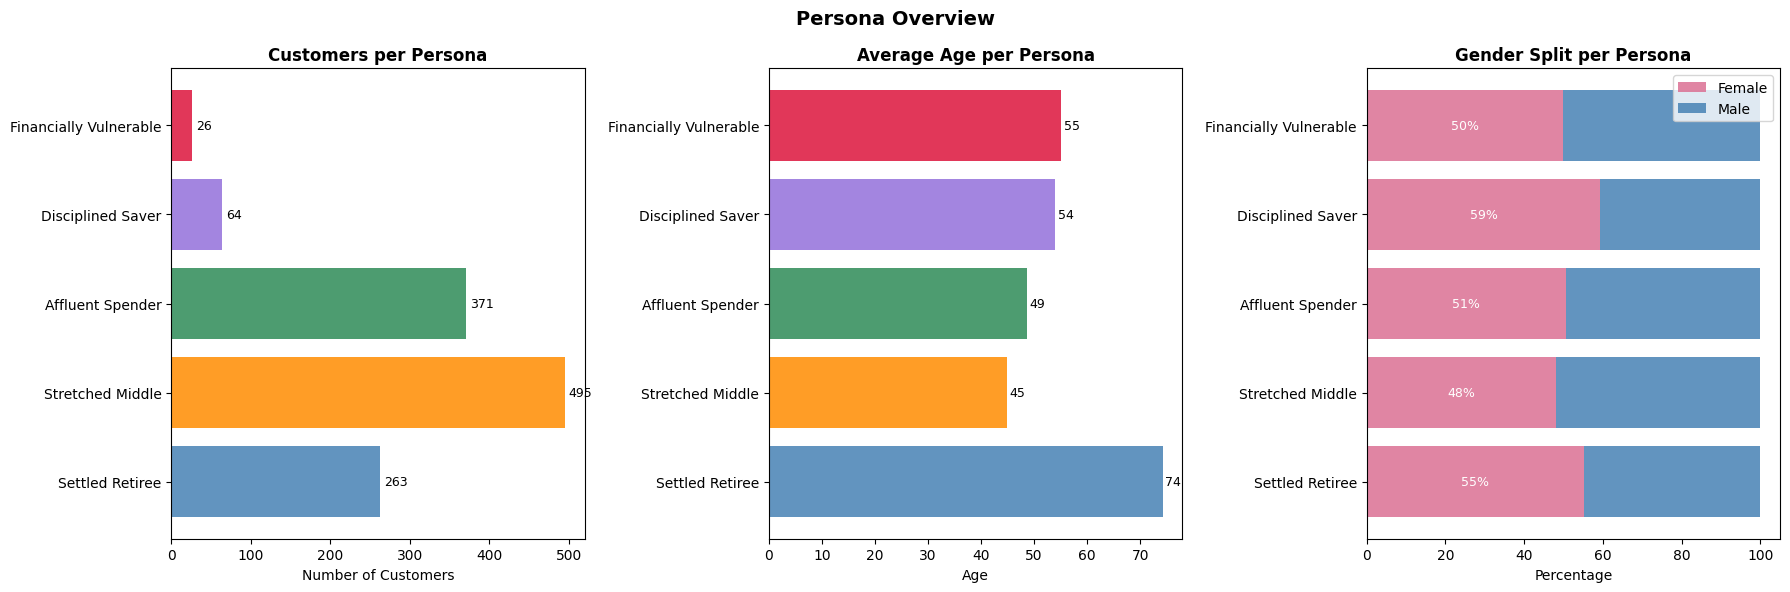

Chart saved


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Chart 1: Cluster sizes ---
personas_ordered = [persona_names[i] for i in range(5)]
sizes = [data[data['cluster'] == i].shape[0] for i in range(5)]
bar_colors = [colors[i] for i in range(5)]

axes[0].barh(personas_ordered, sizes, color=bar_colors, alpha=0.85)
axes[0].set_title('Customers per Persona', fontweight='bold')
axes[0].set_xlabel('Number of Customers')
for i, v in enumerate(sizes):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# --- Chart 2: Average age per persona ---
avg_age = [data[data['cluster'] == i]['current_age'].mean() for i in range(5)]
axes[1].barh(personas_ordered, avg_age, color=bar_colors, alpha=0.85)
axes[1].set_title('Average Age per Persona', fontweight='bold')
axes[1].set_xlabel('Age')
for i, v in enumerate(avg_age):
    axes[1].text(v + 0.5, i, f'{v:.0f}', va='center', fontsize=9)

# --- Chart 3: Gender breakdown ---
female_pct = [
    data[data['cluster'] == i]['gender'].apply(lambda x: x == 'Female').mean() * 100
    for i in range(5)
]
male_pct = [100 - f for f in female_pct]

axes[2].barh(personas_ordered, female_pct, color='palevioletred', alpha=0.85, label='Female')
axes[2].barh(personas_ordered, male_pct, left=female_pct, color='steelblue', alpha=0.85, label='Male')
axes[2].set_title('Gender Split per Persona', fontweight='bold')
axes[2].set_xlabel('Percentage')
axes[2].legend()
for i, v in enumerate(female_pct):
    axes[2].text(v / 2, i, f'{v:.0f}%', va='center', ha='center', fontsize=9, color='white')

plt.suptitle('Persona Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/report_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

/var/folders/t6/42jw6k7923109dbg_p1pvn1m0000gn/T/ipykernel_47292/3887282289.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(personas_ordered, rotation=15, ha='right', fontsize=9)
/var/folders/t6/42jw6k7923109dbg_p1pvn1m0000gn/T/ipykernel_47292/3887282289.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(personas_ordered, rotation=15, ha='right', fontsize=9)
/var/folders/t6/42jw6k7923109dbg_p1pvn1m0000gn/T/ipykernel_47292/3887282289.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(personas_ordered, rotation=15, ha='right', fontsize=9)
/var/folders/t6/42jw6k7923109dbg_p1pvn1m0000gn/T/ipykernel_47292/3887282289.py:15: UserWarning: set_ticklabels() should only be used with a

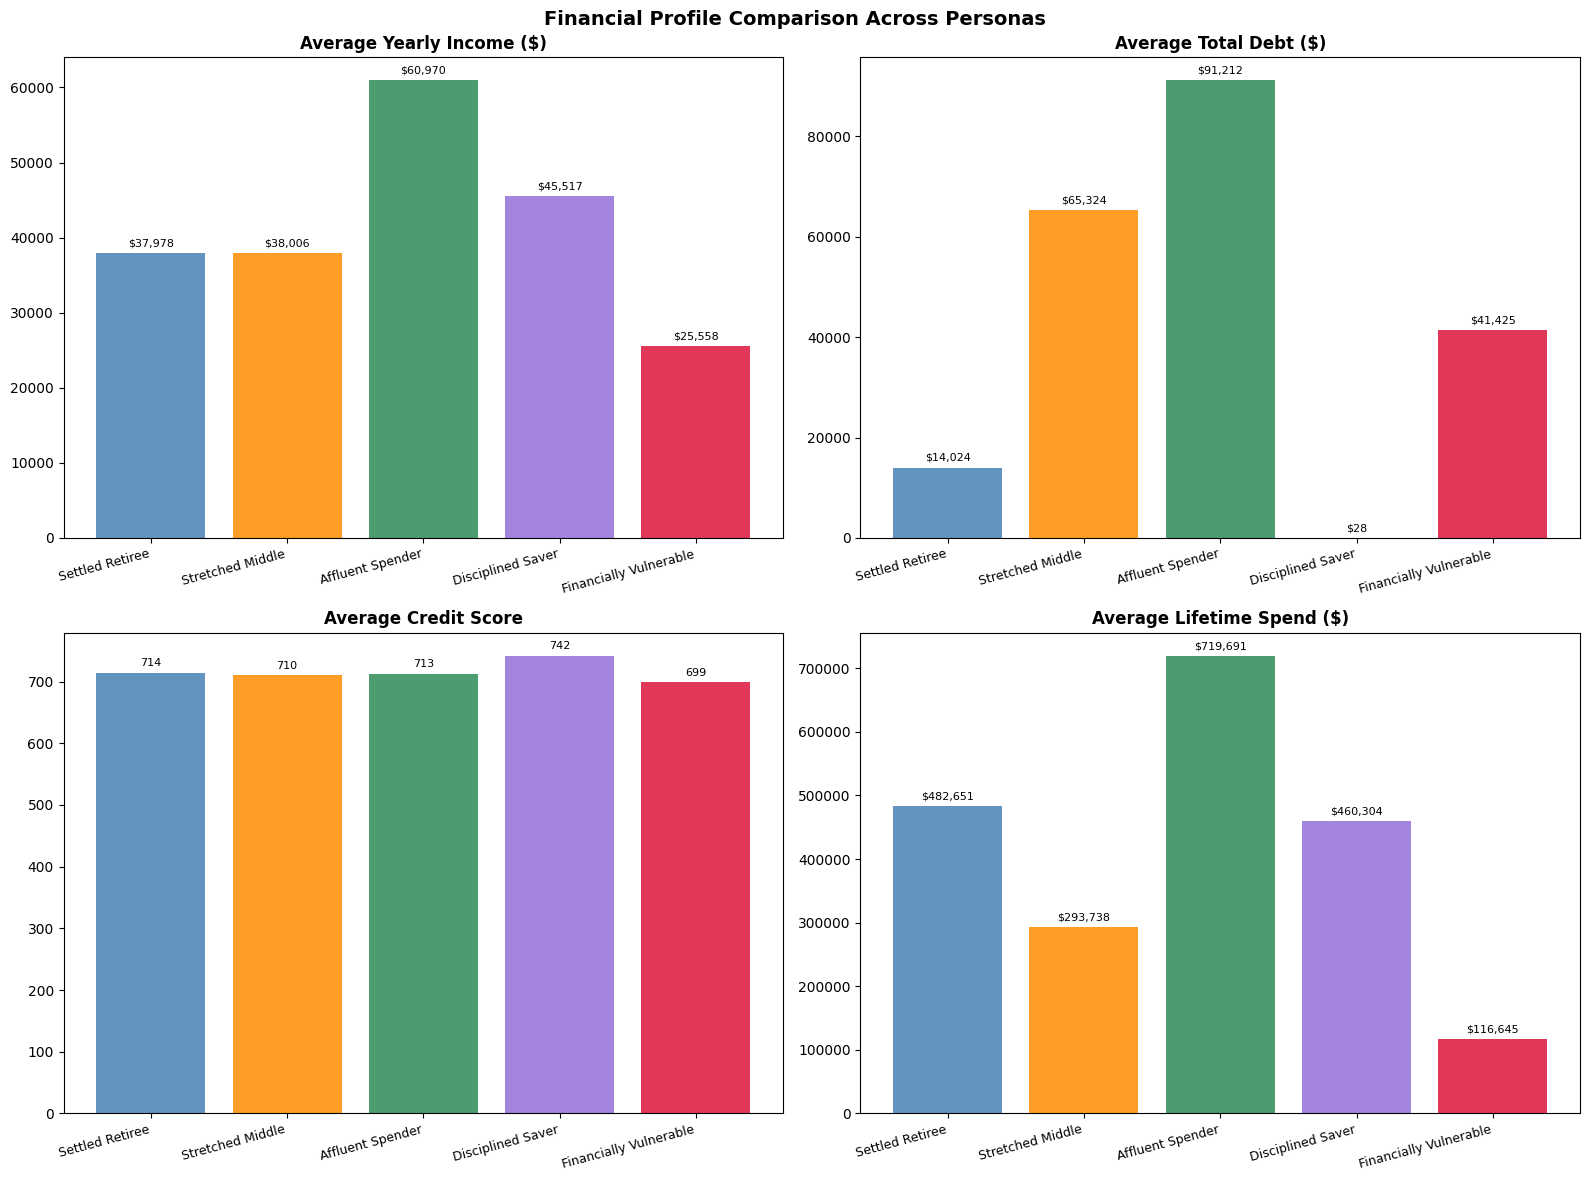

Chart saved


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = [
    ('yearly_income', 'Average Yearly Income ($)', axes[0, 0]),
    ('total_debt', 'Average Total Debt ($)', axes[0, 1]),
    ('credit_score', 'Average Credit Score', axes[1, 0]),
    ('total_spend', 'Average Lifetime Spend ($)', axes[1, 1])
]

for col, title, ax in metrics:
    values = [data[data['cluster'] == i][col].mean() for i in range(5)]
    bar_colors = [colors[i] for i in range(5)]
    bars = ax.bar(personas_ordered, values, color=bar_colors, alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(personas_ordered, rotation=15, ha='right', fontsize=9)
    
    # Add value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.01,
            f'${val:,.0f}' if col != 'credit_score' else f'{val:.0f}',
            ha='center', va='bottom', fontsize=8
        )

plt.suptitle('Financial Profile Comparison Across Personas', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/report_financials.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

## The Five Financial Personas

---

### 🔵 Cluster 0 — The Settled Retiree
**263 customers | Avg age 74 | 55% female**

Past retirement age with low debt and stable spending habits. 
Income is modest but manageable, and credit limits are relatively 
high — likely accumulated over decades. Spending is consistent 
rather than aspirational.

- **More likely:** Fixed routine purchases, low-risk financial behaviour, established merchant relationships
- **Less likely:** New credit applications, large discretionary purchases, debt accumulation

---

### 🟠 Cluster 1 — The Stretched Middle
**495 customers | Avg age 45 | 48% female**

The largest group. Mid-career earners carrying significant debt 
relative to income — the highest debt-to-income ratio of all personas. 
Spending is conservative despite being in peak earning years, 
suggesting financial pressure limits discretionary activity.

- **More likely:** Revolving credit use, essential spending, financial stress indicators
- **Less likely:** Savings products, lifestyle spending, investment activity

---

### 🟢 Cluster 2 — The Affluent Spender
**371 customers | Avg age 49 | 51% female**

Highest income, highest spend, highest debt — but also the highest 
credit limit. These customers borrow and spend freely, shop across 
the widest range of merchants, and drive the largest transaction volumes.

- **More likely:** Premium products, travel, dining, diverse merchant categories
- **Less likely:** Budget constraints, financial caution, limited credit access

---

### 🟣 Cluster 3 — The Disciplined Saver
**64 customers | Avg age 54 | 59% female**

The most financially responsible group. Essentially zero debt, 
highest credit score, moderate spending. A predominantly female 
group that demonstrates that strong credit standing does not 
require high income.

- **More likely:** Debt-free living, consistent saving, responsible credit use
- **Less likely:** Impulse spending, debt products, financial risk-taking

---

### 🔴 Cluster 4 — The Financially Vulnerable
**26 customers | Avg age 55 | 50% female**

The smallest and most financially constrained group. Lowest income, 
near-zero credit limit, lowest spend, and narrowest merchant diversity. 
Despite moderate debt, their access to financial products is severely limited.

- **More likely:** Essential spending only, limited merchant range, financial exclusion
- **Less likely:** Credit products, lifestyle spending, financial flexibility

---